# Arrhythmia model

This notebook trains a fast baseline model to identify ECG records with arrhythmia-related labels. It uses a LightGBM gradient-boosted tree classifier over engineered ECG interval and morphology features. This is a good first architecture here because the dataset already includes structured ECG features, it trains quickly, and it performs well on tabular clinical feature sets without needing a heavy deep-learning stack.

In [1]:
from pathlib import Path
import ast
import pickle
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

## 1. Locate the data

The notebook works whether it is run from the repository root or from inside `notebooks/`.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATASET_DIR = DATA_DIR / "ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1"

if not DATASET_DIR.exists():
    candidates = sorted(DATA_DIR.glob("ptb-xl-*"))
    DATASET_DIR = next((p for p in candidates if p.is_dir()), DATASET_DIR)

assert DATASET_DIR.exists(), f"Dataset folder not found: {DATASET_DIR}"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset dir:  {DATASET_DIR}")

Project root: /Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection
Dataset dir:  /Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/data/ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1


## 2. Load labels and features

The model uses `ecgdeli_features.csv`. I am intentionally not using the 12SL feature table for the first model because part of the target comes from 12SL statements, and keeping those systems separate makes this baseline easier to reason about.

In [3]:
labels_ptbxl = pd.read_csv(DATASET_DIR / "labels" / "ptbxl_statements.csv")
labels_12sl = pd.read_csv(DATASET_DIR / "labels" / "12sl_statements.csv")
snomed = pd.read_csv(DATASET_DIR / "labels" / "snomed_description.csv")
features = pd.read_csv(DATASET_DIR / "features" / "ecgdeli_features.csv")

print("PTB-XL labels:", labels_ptbxl.shape)
print("12SL labels:  ", labels_12sl.shape)
print("SNOMED map:   ", snomed.shape)
print("Features:     ", features.shape)

display(labels_ptbxl.head())
display(features.head())

PTB-XL labels: (21799, 4)
12SL labels:   (21799, 5)
SNOMED map:    (287, 9)
Features:      (21799, 532)


,ecg_id,scp_codes,scp_codes_ext,scp_codes_ext_snomed
0,1,"[('NORM', 100.0), ('LVOLT', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('LVOLT', 100.0), ('SR', 100.0)]","[(320536, 100.0), (441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140,..."
1,2,"[('NORM', 80.0), ('SBRAD', 100.0)]","[('NORM', 80.0), ('SBRAD', 100.0)]","[(134057, 100.0), (321588, 100.0), (440142, 100.0), (441840, 100.0), (3655971, 100.0), (4008453, 100.0), (4010019, 1..."
2,3,"[('NORM', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('SR', 100.0)]","[(441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140, 100.0), (4065279..."
3,4,"[('NORM', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('SR', 100.0)]","[(441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140, 100.0), (4065279..."
4,5,"[('NORM', 100.0), ('SR', 100.0)]","[('NORM', 100.0), ('SR', 100.0)]","[(441840, 100.0), (4008453, 100.0), (4010019, 100.0), (4021775, 100.0), (4023995, 100.0), (4042140, 100.0), (4065279..."


,ecg_id,PQ_Int_I,PQ_Int_I_iqr,PQ_Int_I_count,PQ_Int_II,PQ_Int_II_iqr,PQ_Int_II_count,PQ_Int_III,PQ_Int_III_iqr,PQ_Int_III_count,PQ_Int_V1,PQ_Int_V1_iqr,PQ_Int_V1_count,PQ_Int_V2,PQ_Int_V2_iqr,PQ_Int_V2_count,PQ_Int_V3,PQ_Int_V3_iqr,PQ_Int_V3_count,PQ_Int_V4,PQ_Int_V4_iqr,PQ_Int_V4_count,PQ_Int_V5,PQ_Int_V5_iqr,PQ_Int_V5_count,PQ_Int_V6,PQ_Int_V6_iqr,PQ_Int_V6_count,PQ_Int_aVF,PQ_Int_aVF_iqr,PQ_Int_aVF_count,PQ_Int_aVL,PQ_Int_aVL_iqr,PQ_Int_aVL_count,PQ_Int_aVR,PQ_Int_aVR_iqr,PQ_Int_aVR_count,PQ_Int_Global,PQ_Int_Global_iqr,PQ_Int_Global_count,PR_Int_I,PR_Int_I_iqr,PR_Int_I_count,PR_Int_II,PR_Int_II_iqr,PR_Int_II_count,PR_Int_III,PR_Int_III_iqr,PR_Int_III_count,PR_Int_V1,...,T_Amp_aVF_iqr,T_Amp_aVF_count,T_Amp_aVL,T_Amp_aVL_iqr,T_Amp_aVL_count,T_Amp_aVR,T_Amp_aVR_iqr,T_Amp_aVR_count,T_DurFull_I,T_DurFull_I_iqr,T_DurFull_I_count,T_DurFull_II,T_DurFull_II_iqr,T_DurFull_II_count,T_DurFull_III,T_DurFull_III_iqr,T_DurFull_III_count,T_DurFull_V1,T_DurFull_V1_iqr,T_DurFull_V1_count,T_DurFull_V2,T_DurFull_V2_iqr,T_DurFull_V2_count,T_DurFull_V3,T_DurFull_V3_iqr,T_DurFull_V3_count,T_DurFull_V4,T_DurFull_V4_iqr,T_DurFull_V4_count,T_DurFull_V5,T_DurFull_V5_iqr,T_DurFull_V5_count,T_DurFull_V6,T_DurFull_V6_iqr,T_DurFull_V6_count,T_DurFull_aVF,T_DurFull_aVF_iqr,T_DurFull_aVF_count,T_DurFull_aVL,T_DurFull_aVL_iqr,T_DurFull_aVL_count,T_DurFull_aVR,T_DurFull_aVR_iqr,T_DurFull_aVR_count,T_Dur_Global,T_Dur_Global_iqr,T_Dur_Global_count,HA__Global,HA__Global_iqr,HA__Global_count
0,1,122.0,9.0,11,138.0,6.0,11,204.0,55.0,11,206.0,38.0,11,170.0,29.0,11,172.0,28.0,11,132.0,15.0,11,134.0,16.0,11,154.0,44.0,11,148.0,16.0,11,174.0,17.0,11,132.0,8.0,11,216.0,11.0,11,182.0,8.0,11,198.0,7.0,11,254.0,54.0,11,266.0,...,0.050,11,0.03,0.060,11,-0.18,0.040,11,250.0,86.0,11,142.0,75.0,11,334.0,62.0,11,282.0,115.0,11,146.0,7.0,11,140.0,39.0,11,138.0,6.0,11,140.0,4.0,11,136.0,3.0,11,150.0,27.0,11,314.0,40.0,11,204.0,72.0,11,316.0,24.0,11,2.0,0.0,1
1,2,146.0,2.0,7,176.0,14.0,7,386.0,30.0,7,182.0,70.0,7,180.0,17.0,7,166.0,11.0,7,150.0,7.0,7,150.0,3.0,7,154.0,2.0,7,176.0,90.0,7,190.0,60.0,7,156.0,5.0,7,254.0,150.0,7,202.0,2.0,7,232.0,15.0,7,440.0,29.0,7,240.0,...,0.290,7,0.15,0.175,7,-0.36,0.280,7,274.0,37.0,7,248.0,90.0,7,450.0,101.0,7,146.0,37.0,7,156.0,41.0,7,158.0,4.0,7,148.0,4.0,7,156.0,20.0,7,172.0,84.0,7,354.0,218.0,7,284.0,29.0,7,154.0,70.0,7,352.0,123.0,7,4.0,0.0,1
2,3,134.0,6.0,11,136.0,29.0,11,176.0,81.0,11,204.0,46.0,11,160.0,12.0,11,114.0,43.0,11,128.0,12.0,11,132.0,42.0,11,138.0,26.0,11,176.0,74.0,11,142.0,50.0,11,136.0,22.0,11,222.0,46.0,10,192.0,5.0,11,196.0,33.0,11,238.0,74.0,11,260.0,...,0.200,11,0.13,0.115,11,-0.17,0.090,11,268.0,71.0,11,290.0,87.0,11,326.0,89.0,11,136.0,11.0,11,298.0,110.0,11,166.0,77.0,11,208.0,113.0,11,272.0,87.0,11,154.0,93.0,11,324.0,94.0,11,202.0,92.0,11,208.0,108.0,11,382.0,41.0,11,2.0,0.0,1
3,4,172.0,18.0,13,152.0,28.0,13,172.0,68.0,13,120.0,34.0,13,152.0,64.0,13,100.0,4.0,13,134.0,10.0,13,142.0,14.0,13,142.0,52.0,13,202.0,76.0,13,182.0,56.0,13,144.0,10.0,13,216.0,60.0,13,232.0,18.0,13,210.0,28.0,13,230.0,64.0,13,196.0,...,0.330,13,0.09,0.200,13,-0.34,0.200,13,142.0,2.0,13,152.0,50.0,13,222.0,84.0,13,130.0,8.0,13,148.0,2.0,13,152.0,2.0,13,146.0,4.0,13,142.0,4.0,13,140.0,6.0,13,180.0,60.0,13,246.0,44.0,13,142.0,8.0,13,256.0,76.0,13,4.0,0.0,1
4,5,138.0,65.0,11,142.0,10.0,11,172.0,32.0,11,174.0,32.0,11,170.0,22.0,11,142.0,12.0,11,142.0,5.0,11,146.0,8.0,11,146.0,17.0,11,146.0,19.0,11,240.0,46.0,11,140.0,12.0,11,216.0,36.0,11,214.0,77.0,11,198.0,10.0,11,228.0,33.0,11,230.0,...,0.145,11,-0.04,0.060,11,-0.22,0.115,11,160.0,93.0,11,148.0,51.0,11,204.0,93.0,11,310.0,69.0,11,168.0,5.0,11,150.0,5.0,11,148.0,3.0,11,144.0,4.0,11,144.0,8.0,11,144.0,97.0,11,332.0,128.0,11,154.0,51.0,11,350.0,102.0,11,4.0,0.0,1


## 3. Build an arrhythmia target

This is a practical binary target for a first model. It flags a record when either its expanded PTB-XL SNOMED labels or its 12SL statement codes look arrhythmia-related. Before a final clinical model, review this target definition with your project criteria.

In [4]:
def parse_label_list(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []
    return parsed if isinstance(parsed, list) else []


def explode_weighted_codes(df, list_column, code_name="code", weight_name="confidence"):
    parsed = df[["ecg_id", list_column]].copy()
    parsed[list_column] = parsed[list_column].apply(parse_label_list)
    exploded = parsed.explode(list_column).dropna(subset=[list_column])
    exploded[[code_name, weight_name]] = pd.DataFrame(
        exploded[list_column].tolist(), index=exploded.index
    )
    return exploded.drop(columns=[list_column])


ptbxl_snomed = explode_weighted_codes(
    labels_ptbxl,
    "scp_codes_ext_snomed",
    code_name="snomed_id",
    weight_name="confidence",
)
ptbxl_snomed["snomed_id"] = ptbxl_snomed["snomed_id"].astype("int64")
snomed["snomed_id"] = snomed["snomed_id"].astype("int64")

labels_12sl_codes = explode_weighted_codes(
    labels_12sl,
    "statements_ext",
    code_name="statement_code",
    weight_name="confidence",
)

ARRHYTHMIA_KEYWORDS = re.compile(
    r"arrhythm|fibrillation|flutter|tachy|brady|ectopic|extrasystol|premature|atrioventricular block|av block|heart block|escape rhythm",
    flags=re.IGNORECASE,
)

ARRHYTHMIA_12SL_CODES = {
    "AFIB", "AFLT", "FLUT", "SVARR", "SVTAC", "PSVT", "SARRH", "PACE",
    "SBRAD", "STACH", "SRTH", "SAR", "PAC", "PVC", "PSVC", "PVC2", "VES",
    "BIGU", "TRIGU", "FAV", "VAVB", "AVB", "2AVB", "3AVB", "W2T1", "W3T1", "ABR",
}

arrhythmia_snomed = snomed[
    snomed["description"].fillna("").str.contains(ARRHYTHMIA_KEYWORDS)
    & (snomed["counts_ptbxl"].fillna(0) > 0)
].copy()
arrhythmia_snomed_ids = set(arrhythmia_snomed["snomed_id"])

ptbxl_arrhythmia_ids = set(
    ptbxl_snomed.loc[ptbxl_snomed["snomed_id"].isin(arrhythmia_snomed_ids), "ecg_id"]
)
sl_arrhythmia_ids = set(
    labels_12sl_codes.loc[labels_12sl_codes["statement_code"].isin(ARRHYTHMIA_12SL_CODES), "ecg_id"]
)

all_ids = sorted(set(labels_ptbxl["ecg_id"]) | set(labels_12sl["ecg_id"]))
target = pd.DataFrame({"ecg_id": all_ids})
target["ptbxl_arrhythmia"] = target["ecg_id"].isin(ptbxl_arrhythmia_ids)
target["12sl_arrhythmia"] = target["ecg_id"].isin(sl_arrhythmia_ids)
target["arrhythmia"] = target["ptbxl_arrhythmia"] | target["12sl_arrhythmia"]

display(
    target[["ptbxl_arrhythmia", "12sl_arrhythmia", "arrhythmia"]]
    .agg(["sum", "mean"])
    .T.rename(columns={"sum": "records", "mean": "share"})
)

display(arrhythmia_snomed[["snomed_id", "description", "counts_ptbxl"]].sort_values("counts_ptbxl", ascending=False).head(20))

,records,share
ptbxl_arrhythmia,8516.0,0.390660
12sl_arrhythmia,9430.0,0.432589
arrhythmia,11988.0,0.549933


,snomed_id,description,counts_ptbxl
60,44784217,Cardiac arrhythmia,8011
242,320425,Heart block,4822
133,4064457,EKG: heart block,4412
263,4248028,Supraventricular arrhythmia,2766
177,4068155,Atrial arrhythmia,2207
215,313217,Atrial fibrillation,1514
126,4064452,ECG: atrial fibrillation,1514
191,4226399,Fibrillation,1514
285,4091901,Aberrant premature complexes,1513
83,4089462,Ventricular premature complex,1197


## 4. Prepare the modeling table

`ecg_id` is kept only as an identifier and is not used as a feature.

In [5]:
data = features.merge(target[["ecg_id", "arrhythmia"]], on="ecg_id", how="inner")

X = data.drop(columns=["ecg_id", "arrhythmia"]).select_dtypes(include="number")
X = X.replace([np.inf, -np.inf], np.nan)
y = data["arrhythmia"].astype(int)

all_missing_cols = X.columns[X.isna().all()]
constant_cols = X.columns[X.nunique(dropna=True) <= 1]
drop_cols = sorted(set(all_missing_cols) | set(constant_cols))
X = X.drop(columns=drop_cols)

print("Modeling table:", data.shape)
print("Feature matrix:", X.shape)
print("Dropped low-information columns:", len(drop_cols))
print("Positive class rate:", round(y.mean(), 4))

display(y.value_counts().rename(index={0: "not arrhythmia", 1: "arrhythmia"}).to_frame("records"))

Modeling table: (21799, 533)
Feature matrix: (21799, 529)
Dropped low-information columns: 2
Positive class rate: 0.5499


,records
arrhythmia,
arrhythmia,11988
not arrhythmia,9811


## 5. Train LightGBM

This model is intentionally modest: balanced classes, a few hundred trees, and no expensive hyperparameter search. It should run quickly while giving a useful baseline.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "classifier",
            LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                n_estimators=250,
                learning_rate=0.05,
                num_leaves=31,
                subsample=0.90,
                colsample_bytree=0.90,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
print("Training complete")

Training complete


## 6. Evaluate

ROC AUC is useful, but average precision is often more informative when the arrhythmia class is imbalanced.

ROC AUC: 0.9546
Average precision: 0.9661

                precision    recall  f1-score   support

not arrhythmia       0.85      0.92      0.88      1962
    arrhythmia       0.93      0.86      0.90      2398

      accuracy                           0.89      4360
     macro avg       0.89      0.89      0.89      4360
  weighted avg       0.89      0.89      0.89      4360



/Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/ecg-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


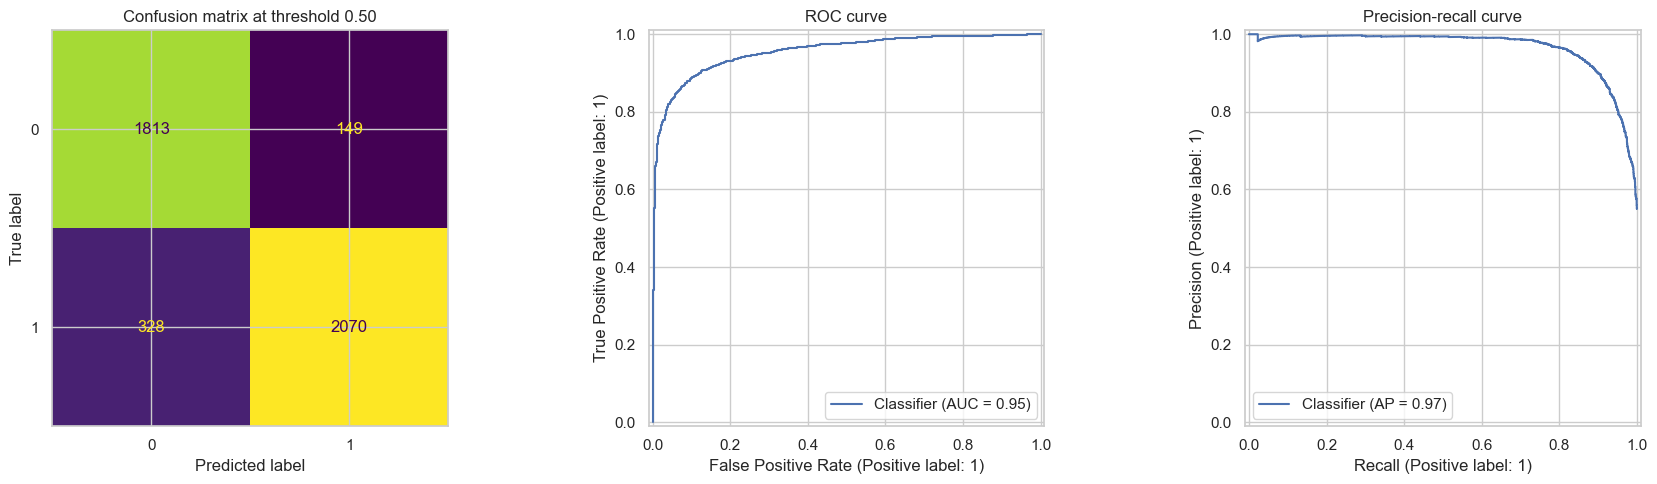

In [7]:
proba_test = model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.50).astype(int)

print("ROC AUC:", round(roc_auc_score(y_test, proba_test), 4))
print("Average precision:", round(average_precision_score(y_test, proba_test), 4))
print()
print(classification_report(y_test, pred_test, target_names=["not arrhythmia", "arrhythmia"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix at threshold 0.50")
RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1])
axes[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[2])
axes[2].set_title("Precision-recall curve")
plt.tight_layout()
plt.show()

## 7. Pick a threshold

The default 0.50 threshold is not always best for medical screening tasks. This cell chooses the threshold that maximizes F1 on the test set for a simple demonstration. For a real final model, tune the threshold on a validation set instead.

Best F1 threshold: 0.334
Precision: 0.897
Recall:    0.905
F1:        0.901

                precision    recall  f1-score   support

not arrhythmia       0.88      0.87      0.88      1962
    arrhythmia       0.90      0.91      0.90      2398

      accuracy                           0.89      4360
     macro avg       0.89      0.89      0.89      4360
  weighted avg       0.89      0.89      0.89      4360



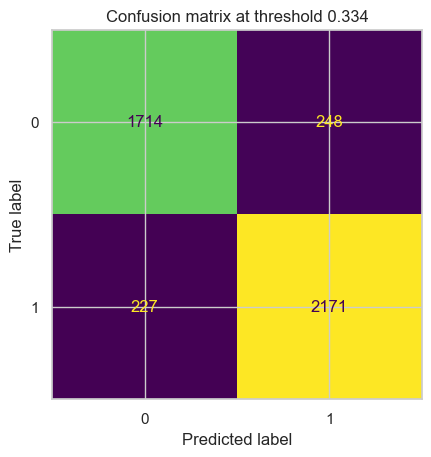

In [8]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_test)
f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
best_idx = int(np.nanargmax(f1))
best_threshold = float(thresholds[best_idx])
best_pred = (proba_test >= best_threshold).astype(int)

print(f"Best F1 threshold: {best_threshold:.3f}")
print(f"Precision: {precision[best_idx]:.3f}")
print(f"Recall:    {recall[best_idx]:.3f}")
print(f"F1:        {f1[best_idx]:.3f}")
print()
print(classification_report(y_test, best_pred, target_names=["not arrhythmia", "arrhythmia"]))

ConfusionMatrixDisplay.from_predictions(y_test, best_pred, colorbar=False)
plt.title(f"Confusion matrix at threshold {best_threshold:.3f}")
plt.show()

## 8. Feature importance

,feature,importance
0,RR_Mean_Global,358
1,RR_Mean_Global_iqr,187
2,S_Amp_V1,164
3,R_Amp_aVR,115
4,R_Amp_V1,109
5,S_Amp_V2,80
6,QT_IntCorr_V2_iqr,78
7,QRS_Dur_V1,77
8,S_Amp_V6,73
9,T_Dur_Global_iqr,71


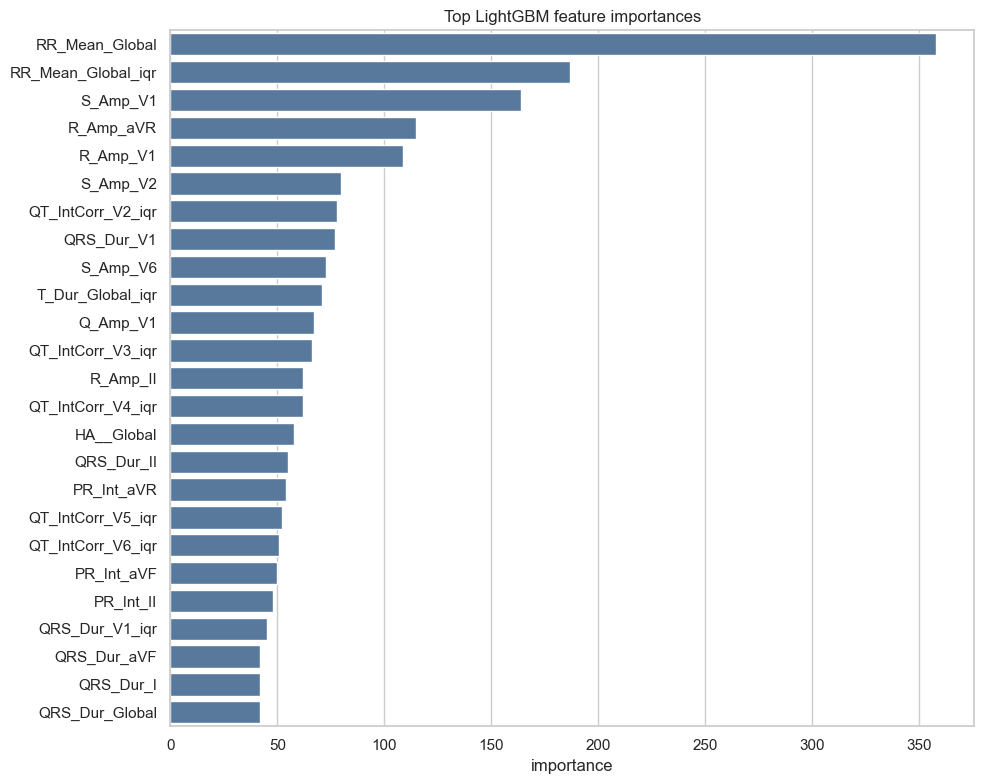

In [9]:
feature_importance = (
    pd.DataFrame(
        {
            "feature": X.columns,
            "importance": model.named_steps["classifier"].feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(30))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(25), x="importance", y="feature", color="#4C78A8")
plt.title("Top LightGBM feature importances")
plt.xlabel("importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 9. Save the model

The saved object includes the pipeline, feature names, and selected threshold.

In [10]:
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

model_artifact = {
    "model": model,
    "feature_columns": X.columns.tolist(),
    "threshold": best_threshold,
    "feature_table": "ecgdeli_features.csv",
    "target": "arrhythmia",
}

model_path = MODEL_DIR / "arrhythmia_lightgbm.pkl"
with model_path.open("wb") as f:
    pickle.dump(model_artifact, f)

model_path

PosixPath('/Users/gubscruz/INSPER/7_PERIODO/ai-medicine/ecg-anomaly-detection/models/arrhythmia_lightgbm.pkl')